In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from geometry_class import Geometry
from parametrizations import Parameter
from visualization_fct import get_grid, eval_fct_on_grid
from dolfinx.fem import functionspace, Function
import pickle

In [7]:
filename = "Moure_test_coupling"
with open("./solutions/"+filename+".pkl", "rb") as f:
    data_Annika = pickle.load(f)

nx = data_Annika["geometry"]["nx"]
nz = data_Annika["geometry"]["nz"]
interval = data_Annika["saving_interval"]
geom = Geometry()
geom.make_from_dict(data_Annika["geometry"])
domain = geom.make_domain(nx, nz)
[P0, P1, P2, P3] = geom.corner_points
V = functionspace(domain, ("CG", 1))
Q = functionspace(domain, ("DG", 0))
hw = Function(V)
phi = Function(Q)
T_i = Function(V)
T_w = Function(V)
p = Parameter(domain)
grid, x_plot, z_plot = get_grid(P0, P1, P2, P3, nx, nz)

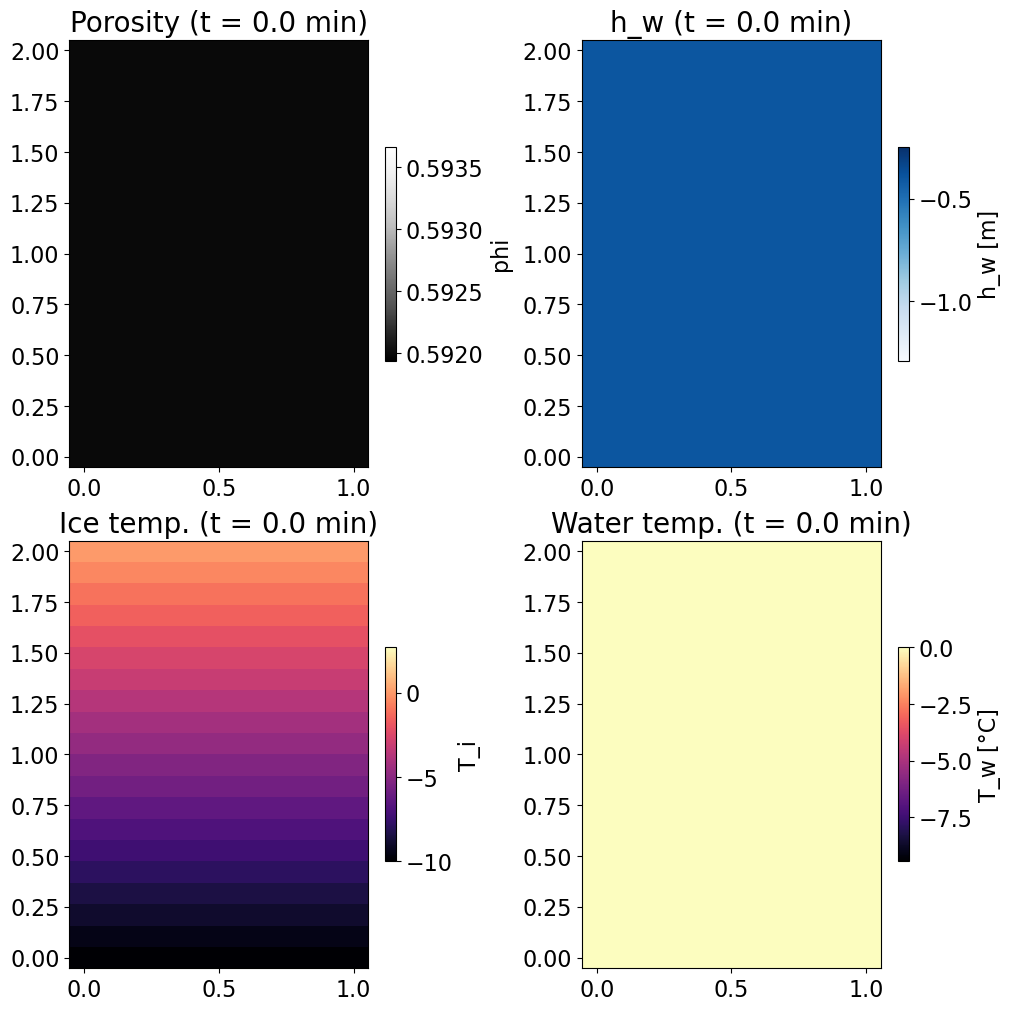

In [9]:
import matplotlib.animation as animation

# Setup figure and axes
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(2, 2, layout="constrained", figsize=(10, 10))

# Initial values
t_obs = 0
hw.x.array[:] = data_Annika["h_w"][t_obs]
phi.x.array[:] = data_Annika["phi"][t_obs]
T_i.x.array[:] = data_Annika["T_i"][t_obs]
T_w.x.array[:] = data_Annika["T_w"][t_obs]
pressure_head = eval_fct_on_grid(grid, hw, domain).reshape((nz, nx))
porosity = eval_fct_on_grid(grid, phi, domain).reshape((nz, nx))
Ti = eval_fct_on_grid(grid, T_i, domain).reshape((nz, nx))
Tw = eval_fct_on_grid(grid, T_w, domain).reshape((nz, nx))

# Initial plots (empty or first frame)
pmsh1 = ax[0, 0].pcolormesh(
    x_plot, z_plot, porosity, cmap="Greys_r",
    vmin=np.min(data_Annika["phi"]), vmax=np.max(data_Annika["phi"]))
ax[0, 0].set_title("Porosity", fontsize=20)
cbar1 = fig.colorbar(pmsh1, ax=ax[0, 0], shrink=0.5)
cbar1.set_label("phi")

pmsh2 = ax[0, 1].pcolormesh(
    x_plot, z_plot, pressure_head, cmap="Blues",
    vmin=np.min(data_Annika["h_w"]), vmax=np.max(data_Annika["h_w"]))
ax[0, 1].set_title("h_w", fontsize=20)
cbar2 = fig.colorbar(pmsh2, ax=ax[0, 1], shrink=0.5)
cbar2.set_label("h_w [m]")

pmsh3 = ax[1, 0].pcolormesh(
    x_plot, z_plot, Ti, cmap="magma",
    vmin=np.min(data_Annika["T_i"]), vmax=np.max(data_Annika["T_i"]))
ax[1, 0].set_title("Ice temp.", fontsize=20)
cbar3 = fig.colorbar(pmsh3, ax=ax[1, 0], shrink=0.5)
cbar3.set_label("T_i")

pmsh4 = ax[1, 1].pcolormesh(
    x_plot, z_plot, Tw, cmap="magma",
    vmin=np.min(data_Annika["T_w"]), vmax=np.max(data_Annika["T_w"]))
ax[1, 1].set_title("Water temp.", fontsize=20)
cbar4 = fig.colorbar(pmsh4, ax=ax[1, 1], shrink=0.5)
cbar4.set_label("T_w [°C]")

# Update function for each frame


def update(frame):
    t_obs = frame
    hw.x.array[:] = data_Annika["h_w"][t_obs]
    phi.x.array[:] = data_Annika["phi"][t_obs]
    T_i.x.array[:] = data_Annika["T_i"][t_obs]
    T_w.x.array[:] = data_Annika["T_w"][t_obs]

    pressure_head = eval_fct_on_grid(grid, hw, domain).reshape((nz, nx))
    porosity = eval_fct_on_grid(grid, phi, domain).reshape((nz, nx))
    Ti = eval_fct_on_grid(grid, T_i, domain).reshape((nz, nx))
    Tw = eval_fct_on_grid(grid, T_w, domain).reshape((nz, nx))
    time = data_Annika["times"][t_obs]

    pmsh1.set_array(porosity.ravel())
    pmsh2.set_array(pressure_head.ravel())
    pmsh3.set_array(Ti.ravel())
    pmsh4.set_array(Tw.ravel())

    ax[0, 0].set_title(f"Porosity (t = {time/60:.1f} min)", fontsize=20)
    ax[0, 1].set_title(f"h_w (t = {time/60:.1f} min)", fontsize=20)
    ax[1, 0].set_title(f"Ice temp. (t = {time/60:.1f} min)", fontsize=20)
    ax[1, 1].set_title(f"Water temp. (t = {time/60:.1f} min)", fontsize=20)

    return pmsh1, pmsh2, pmsh3, pmsh4


# Create animation
num_frames = len(data_Annika["T_w"])  # or your max time index
ani = animation.FuncAnimation(
    fig,
    update,
    frames=num_frames,
    interval=200,  # ms between frames
    blit=False,
    repeat=True
)

# Save animation
ani.save("./animations/"+ filename + ".mp4", writer="ffmpeg", fps=5)